# 01. 건강검진 데이터 이해 (Data Understanding)

이 노트북에서는 국민건강보험공단 건강검진정보 2024 데이터의 구조를 파악합니다.

## 목차
1. 데이터 로딩
2. 기본 정보 확인 (행/열, 컬럼 목록)
3. 컬럼별 결측률
4. 주요 변수 분포 확인

In [1]:
# 라이브러리 가져오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 한글 폰트 (matplotlib)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로딩

In [2]:
# CP949 인코딩으로 CSV 읽기 (한국 공공데이터 표준)
df = pd.read_csv(
    '../data/raw/2024_국민건강보험공단_건강검진정보.CSV',
    encoding='cp949'
)
print(f'데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열')

데이터 크기: 1,000,000행 × 33열


## 2. 기본 정보 확인

In [3]:
# 컬럼 목록
print('=== 33개 컬럼 ===')
for i, col in enumerate(df.columns):
    print(f'  {i+1:2}. {col}')

=== 33개 컬럼 ===
   1. 기준년도
   2. 가입자일련번호
   3. 시도코드
   4. 성별코드
   5. 연령대코드(5세단위)
   6. 신장(5cm단위)
   7. 체중(5kg단위)
   8. 허리둘레
   9. 시력(좌)
  10. 시력(우)
  11. 청력(좌)
  12. 청력(우)
  13. 수축기혈압
  14. 이완기혈압
  15. 식전혈당(공복혈당)
  16. 총콜레스테롤
  17. 트리글리세라이드
  18. HDL콜레스테롤
  19. LDL콜레스테롤
  20. 혈색소
  21. 요단백
  22. 혈청크레아티닌
  23. 혈청지오티(AST)
  24. 혈청지피티(ALT)
  25. 감마지티피
  26. 흡연상태
  27. 음주여부
  28. 구강검진수검여부
  29. 치아우식증유무
  30. 결손치 유무
  31. 치아마모증유무
  32. 제3대구치(사랑니) 이상
  33. 치석


In [4]:
# 처음 5개 행 미리보기
df.head()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),...,혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,결손치 유무,치아마모증유무,제3대구치(사랑니) 이상,치석
0,2024,4831755,41,2,13,160,50,70.0,1.0,1.0,...,13.0,6.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
1,2024,1154608,41,2,11,155,60,74.9,1.0,1.0,...,10.0,14.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
2,2024,3318236,41,2,13,150,55,74.0,1.0,1.0,...,19.0,17.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
3,2024,3770599,41,1,16,160,70,89.0,1.0,1.0,...,26.0,28.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
4,2024,2634185,41,1,11,175,65,76.0,1.0,1.0,...,18.0,12.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN


## 3. 결측률 확인

In [5]:
# 컬럼별 결측 비율 계산
missing_rates = (df.isnull().mean() * 100).round(2)
missing_rates = missing_rates[missing_rates > 0].sort_values(ascending=False)
print('결측률이 있는 컬럼:')
print(missing_rates)

결측률이 있는 컬럼:
결손치 유무           100.00
치아마모증유무          100.00
제3대구치(사랑니) 이상    100.00
LDL콜레스테롤          66.36
총콜레스테롤            65.76
HDL콜레스테롤          65.76
트리글리세라이드          65.76
치아우식증유무           65.46
치석                65.46
요단백                1.13
혈색소                0.59
혈청크레아티닌            0.59
혈청지오티(AST)         0.58
수축기혈압              0.58
식전혈당(공복혈당)         0.58
이완기혈압              0.58
감마지티피              0.58
혈청지피티(ALT)         0.58
허리둘레               0.05
시력(좌)              0.02
시력(우)              0.02
청력(좌)              0.01
청력(우)              0.01
흡연상태               0.01
dtype: float64


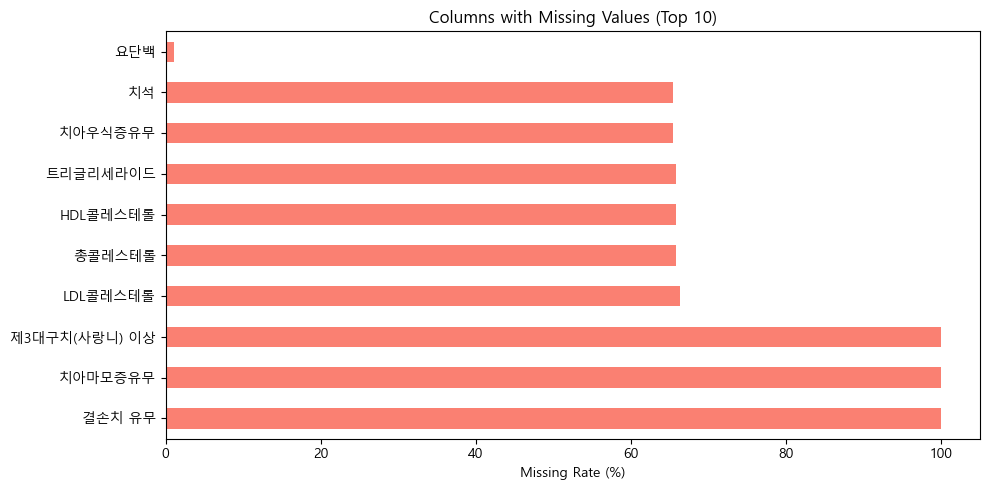

In [6]:
# 결측률 시각화 (상위 10개)
fig, ax = plt.subplots(figsize=(10, 5))
missing_rates.head(10).plot(kind='barh', ax=ax, color='salmon')
ax.set_xlabel('Missing Rate (%)')
ax.set_title('Columns with Missing Values (Top 10)')
plt.tight_layout()
plt.show()

**관찰**: 콜레스테롤 4종(LDL, HDL, 트리글리세라이드, 총콜레스테롤)이 약 66% 결측.
→ 이상지질혈증 검사를 받은 사람만 값이 있기 때문.
→ 모델 학습 변수에서 제외하고, 룰 기반 해석에만 사용 결정.

## 4. 주요 변수 분포

In [7]:
# 성별 분포
print('성별 코드 분포:')
print(df['성별코드'].value_counts())
print('\n1=남성, 2=여성')

성별 코드 분포:
성별코드
1    517930
2    482070
Name: count, dtype: int64

1=남성, 2=여성


In [8]:
# 연령대 분포
age_label_map = {
    5:'25-29세', 6:'30-34세', 7:'35-39세', 8:'40-44세',
    9:'45-49세', 10:'50-54세', 11:'55-59세', 12:'60-64세',
    13:'65-69세', 14:'70-74세', 15:'75-79세', 16:'80-84세', 
    17:'85-89세', 18:'90+세'
}
age_dist = df['연령대코드(5세단위)'].map(age_label_map).value_counts().sort_index()
print('연령대별 인원수:')
print(age_dist)

연령대별 인원수:
연령대코드(5세단위)
25-29세     31190
30-34세     68190
35-39세     92639
40-44세     73825
45-49세    113355
50-54세     91413
55-59세    123996
60-64세    100194
65-69세    113316
70-74세     73995
75-79세     62595
80-84세     27706
85-89세     20993
90+세        6593
Name: count, dtype: int64


In [9]:
# 주요 변수 통계
key_cols = ['신장(5cm단위)', '체중(5kg단위)', '허리둘레',
            '수축기혈압', '이완기혈압', '식전혈당(공복혈당)']
df[key_cols].describe().round(1)

,신장(5cm단위),체중(5kg단위),허리둘레,수축기혈압,이완기혈압,식전혈당(공복혈당)
count,1000000.0,1000000.0,999505.0,994210.0,994211.0,994153.0
mean,162.7,64.6,81.6,122.7,75.2,101.0
std,9.4,14.0,10.9,14.6,10.4,23.0
min,130.0,30.0,6.8,60.0,11.0,17.0
25%,155.0,55.0,74.0,112.0,68.0,89.0
50%,165.0,65.0,81.2,121.0,75.0,96.0
75%,170.0,75.0,88.5,132.0,81.0,106.0
max,195.0,135.0,999.0,271.0,182.0,991.0


## 결론

- **데이터 규모**: 100만 건 × 33컬럼
- **필수 변수(성별/나이/키/몸무게/혈압/혈당)**: 결측률 1% 미만으로 양호
- **콜레스테롤 4종**: 약 66% 결측 → 모델 학습에는 미사용
- **다음 단계**: 02_preprocessing_eda.ipynb에서 결측치·이상치 처리 및 파생변수 생성